In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math

import os

import sys

sys.path.append('../mcap')



In [2]:
ll_df = pd.read_csv("data/results.csv")

In [3]:
from scipy.stats import chi2 as qchisq

from scipy import linalg
from math import ceil
import numpy as np

from loess_1d import loess_1d

def fit_wls(x, y, w):
    X = np.column_stack([np.ones_like(x), -(x**2), x])

    # weighted least squares
    sw = np.sqrt(w)
    Xw = X * sw[:, None]
    yw = y * sw

    coef, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
    c, a, b  = map(float, coef)

    # residual based variance estimate
    yhat = X @ coef
    resid = (y - yhat) * sw
    df = int(np.sum(w > 0) - X.shape[1])
    s2 = float(np.sum(resid**2) / df)

    XtWX     = Xw.T @ Xw
    cov_full = s2 * np.linalg.pinv(XtWX)

    vc_ab = cov_full[1:3, 1:3]
    return a, b, c, vc_ab

def mcap_loglikelihood(loglik_profile_values, param_search, confidence=0.95, span=0.75, n_grid=1000):
    df_data       = pd.DataFrame(columns=["lp", "b", "a"])
    df_data["b"]  = param_search
    df_data["a"]  = param_search**2

    param_grid = np.linspace(min(param_search), max(param_search), n_grid)

    loglik_values = loglik_profile_values[np.argsort(param_search)]
    param_search  = param_search[np.argsort(param_search)]

    df_data["lp"] = loglik_values

    _, loglik_sm, _ = loess_1d(x=param_search, y=loglik_values,
                                        xnew=param_grid,
                                        degree=2, frac=span)

    arg_max    = np.argmax(loglik_sm)
    p_mle_sm  = param_grid[arg_max]

    disttance = abs(param_search-p_mle_sm)
    max_dist  = np.max(disttance)

    weights = np.full(len(param_search), np.nan)
    weights = (1-(disttance/max_dist)**3)**3
    weights = {param_search[idx_p]: weights[idx_p] for idx_p in range(weights.shape[0])}

    df_data["weights"] = df_data["b"].replace(weights)

    a, b, c, cov = fit_wls(df_data["b"].values, df_data["lp"].values, df_data["weights"].values)
    var_a  = cov[0, 0]
    var_b  = cov[1, 1]
    cov_ab = cov[0, 1]

    se_mc_squared    = (1 / (4 * a**2)) * (var_b - (2 * b/a) * cov_ab + (b**2 / a**2) * var_a)
    se_stat_squared  = 1/(2*a)
    se_total_squared = se_mc_squared + se_stat_squared
    loglik_diff      = min(loglik_sm) -  loglik_sm

    delta            = qchisq.ppf(confidence, 1) * (a * se_mc_squared + 0.5)
    #ci              = param_grid[np.where(loglik_diff < delta)]

    ci = param_grid[loglik_sm > (max(loglik_sm) - delta)][[0, -1]]

    if ci.shape[0]>0:
        ci_low           = ci[0]
        ci_high          = ci[-1]
    else:
        ci_low           = None
        ci_high          = None

    confidence = int(confidence*100)
    param_mle_df               = pd.DataFrame(columns=["mle", "delta", f"{confidence}_high", f"{confidence}_low"])
    param_mle_df["mle"]        = [param_grid[arg_max]]
    param_mle_df["se_stat"]    = [se_stat_squared]
    param_mle_df["se_mc"]      = [se_mc_squared]
    param_mle_df[f"{confidence}_low"]  = [ci_low]
    param_mle_df[f"{confidence}_high"] = [ci_high]

    fit_df                  = pd.DataFrame(columns=["parameter", "loglik_smooth", "quadratic"])
    fit_df["parameter"]     = param_grid
    fit_df["loglik_smooth"] = loglik_sm
    fit_df["quadratic"]     = a * param_grid**2 + b * param_grid + c

    return fit_df, param_mle_df

In [4]:
from pypomp import mcap

ll_sm_df = ll_df[ll_df.bEP.between(-1, 1)]
ll_sm_df = ll_sm_df[ll_sm_df.loglik > -2300]

param_arr = ll_sm_df["bEP"].values
ll_arr    = ll_sm_df["loglik"].values

loglik_values = ll_arr[np.argsort(param_arr)]
param_search  = param_arr[np.argsort(param_arr)]

mcap_out = mcap(param_arr, ll_arr, level=0.95, span=0.75, n_grid=5000)


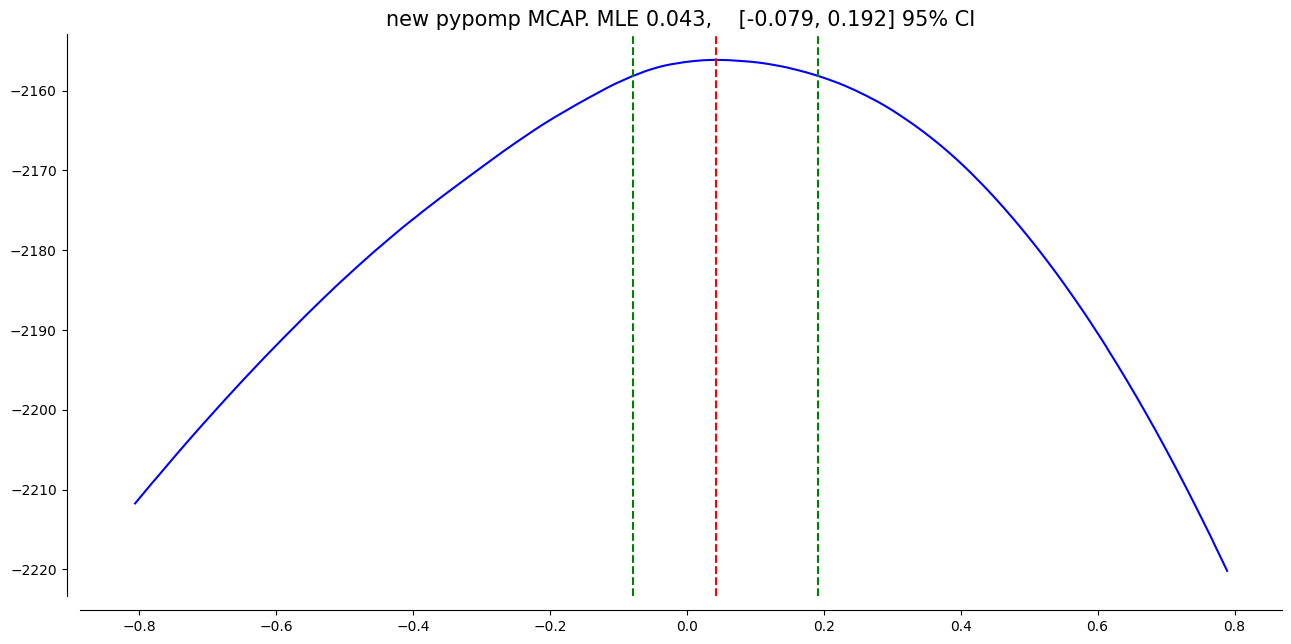

In [5]:
mcap_df            = pd.DataFrame(mcap_out.fit)
mcap_df["mle"]     = mcap_out.mle
mcap_df["ci_low"]  = mcap_out.ci[0]
mcap_df["ci_high"] = mcap_out.ci[1]

fig, ax = plt.subplots(1, 1, figsize=(15.5, 7.3))

ax.plot(mcap_df["parameter"], mcap_df["smoothed"], color="blue", label="Smoothed loglikelihood")

ax.axvline(x=mcap_df.mle[0],     color="red", linestyle="--", label="MLE")
ax.axvline(x=mcap_df.ci_low[0],  color="green", linestyle="--", label="95% CI low")
ax.axvline(x=mcap_df.ci_high[0], color="green", linestyle="--", label="95% CI high")

ax.set_title("new pypomp MCAP. MLE {:0.3f},    [{:0.3f}, {:0.3f}] 95% CI".format(mcap_df.mle[0],
                                                mcap_df.ci_low[0],
                                                mcap_df.ci_high[0]), fontsize=15)
ax.spines["bottom"].set_position(('outward', 10)) # outward by 50 points
ax.spines["left"].set_position(('outward', 10))   # outward by 10 points
ax.spines[['right', 'top']].set_visible(False)


In [6]:
p_df, ci_df = mcap_loglikelihood(ll_arr, param_arr, confidence=0.95, span=0.75, n_grid=1000)


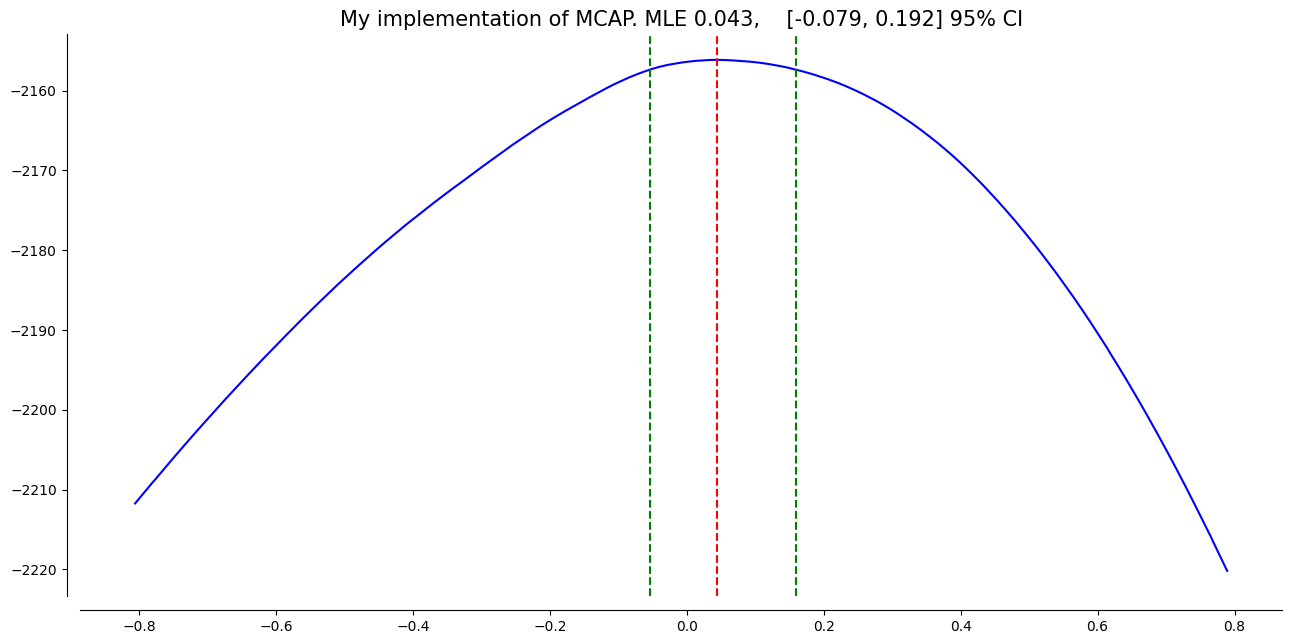

In [7]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(15.5, 7.3))

ax.plot(p_df["parameter"], p_df["loglik_smooth"], color="blue", label="Smoothed loglikelihood")

ax.axvline(x=ci_df.mle[0],     color="red", linestyle="--", label="MLE")
ax.axvline(x=ci_df["95_high"][0],  color="green", linestyle="--", label="95% CI low")
ax.axvline(x=ci_df["95_low"][0], color="green", linestyle="--", label="95% CI high")

ax.set_title("My implementation of MCAP. MLE {:0.3f},    [{:0.3f}, {:0.3f}] 95% CI".format(mcap_df.mle[0],
                                                mcap_df.ci_low[0],
                                                mcap_df.ci_high[0]), fontsize=15)
ax.spines["bottom"].set_position(('outward', 10)) # outward by 50 points
ax.spines["left"].set_position(('outward', 10))   # outward by 10 points
ax.spines[['right', 'top']].set_visible(False)


ax.spines["bottom"].set_position(('outward', 10)) # outward by50 points
ax.spines["left"].set_position(('outward', 10))   # outward by 10 points
ax.spines[['right', 'top']].set_visible(False)

#ax.set_ylim([-2300, -2140])